In [1]:
import sys
sys.path.append('../src')

In [7]:
import jax
import jax.numpy as jnp
import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.train import create_train_state, train_step
from pinn.cryoet_io import load_mrc_data
import pickle
from flax.training import checkpoints
from pinn.utils import initial_loss
from pinn.train import train_step
from tqdm.notebook import trange

GRID_SIZE = 64
NUM_CHECKPOINTS_TO_KEEP = 1000  # Checkpoint retention count (older ones get removed)

# Set loss function weights
lambda_1 = 1000000      # Weight for boundary loss
lambda_2 = 0            # Weight for physics loss
shape = "bud_04"
sdf_pretrain="sphere"   # sphere or plane
flip_ratio=0.2


/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/bud_04/lambda_1000000_0
Resizing MRC data from (128, 128, 128) to (64, 64, 64)


TypeError: 'NoneType' object is not subscriptable

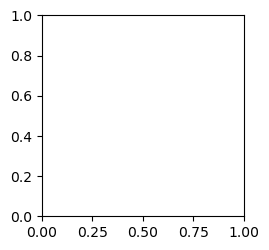

In [8]:
## make one combined image file

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
# lambda_1 = 1000000
# lambda_2 = 100
num_collocation = 10000
# num_collocation = 1000
num_layers = 2
# shape = "bud"


# steps_to_visualize = [0, 200, 600, 1000]
# steps_series = list(range(0, 1001, 100))
steps_to_visualize = [0, 100, 1000, 10000]
steps_series = list(range(0, 10001, 100))

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(3*4, 12))

# Row 1: visualize_cryoET_with_contours
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=32, axis="z")
    if i == 0:
        ax.set_ylabel("CryoET + Contours")

# Row 2: visualize_checkpoint_result
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z")
    if i == 0:
        ax.set_ylabel("Level-set function")

# Row 3: plot_3d_isosurface
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint_data[step], grid_size=GRID_SIZE)
    if i == 0:
        ax.set_zlabel("3D Isosurface", rotation=180)

# Row 4: loss history
assembled_loss = assemble_loss_history(checkpoint_data)
ax = fig.add_subplot(4, 4, 12+1)
plot_loss_history_ax(ax, assembled_loss)
for i in [0,1,2]:
    ax = fig.add_subplot(4, 4, 12+i+2)
    plot_normalized_loss_history_ax(ax, i, assembled_loss)
    

info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = 0.05, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/analysis.png", dpi=300, bbox_inches="tight")
plt.show()

Resizing MRC data from (128, 128, 128) to (64, 64, 64)


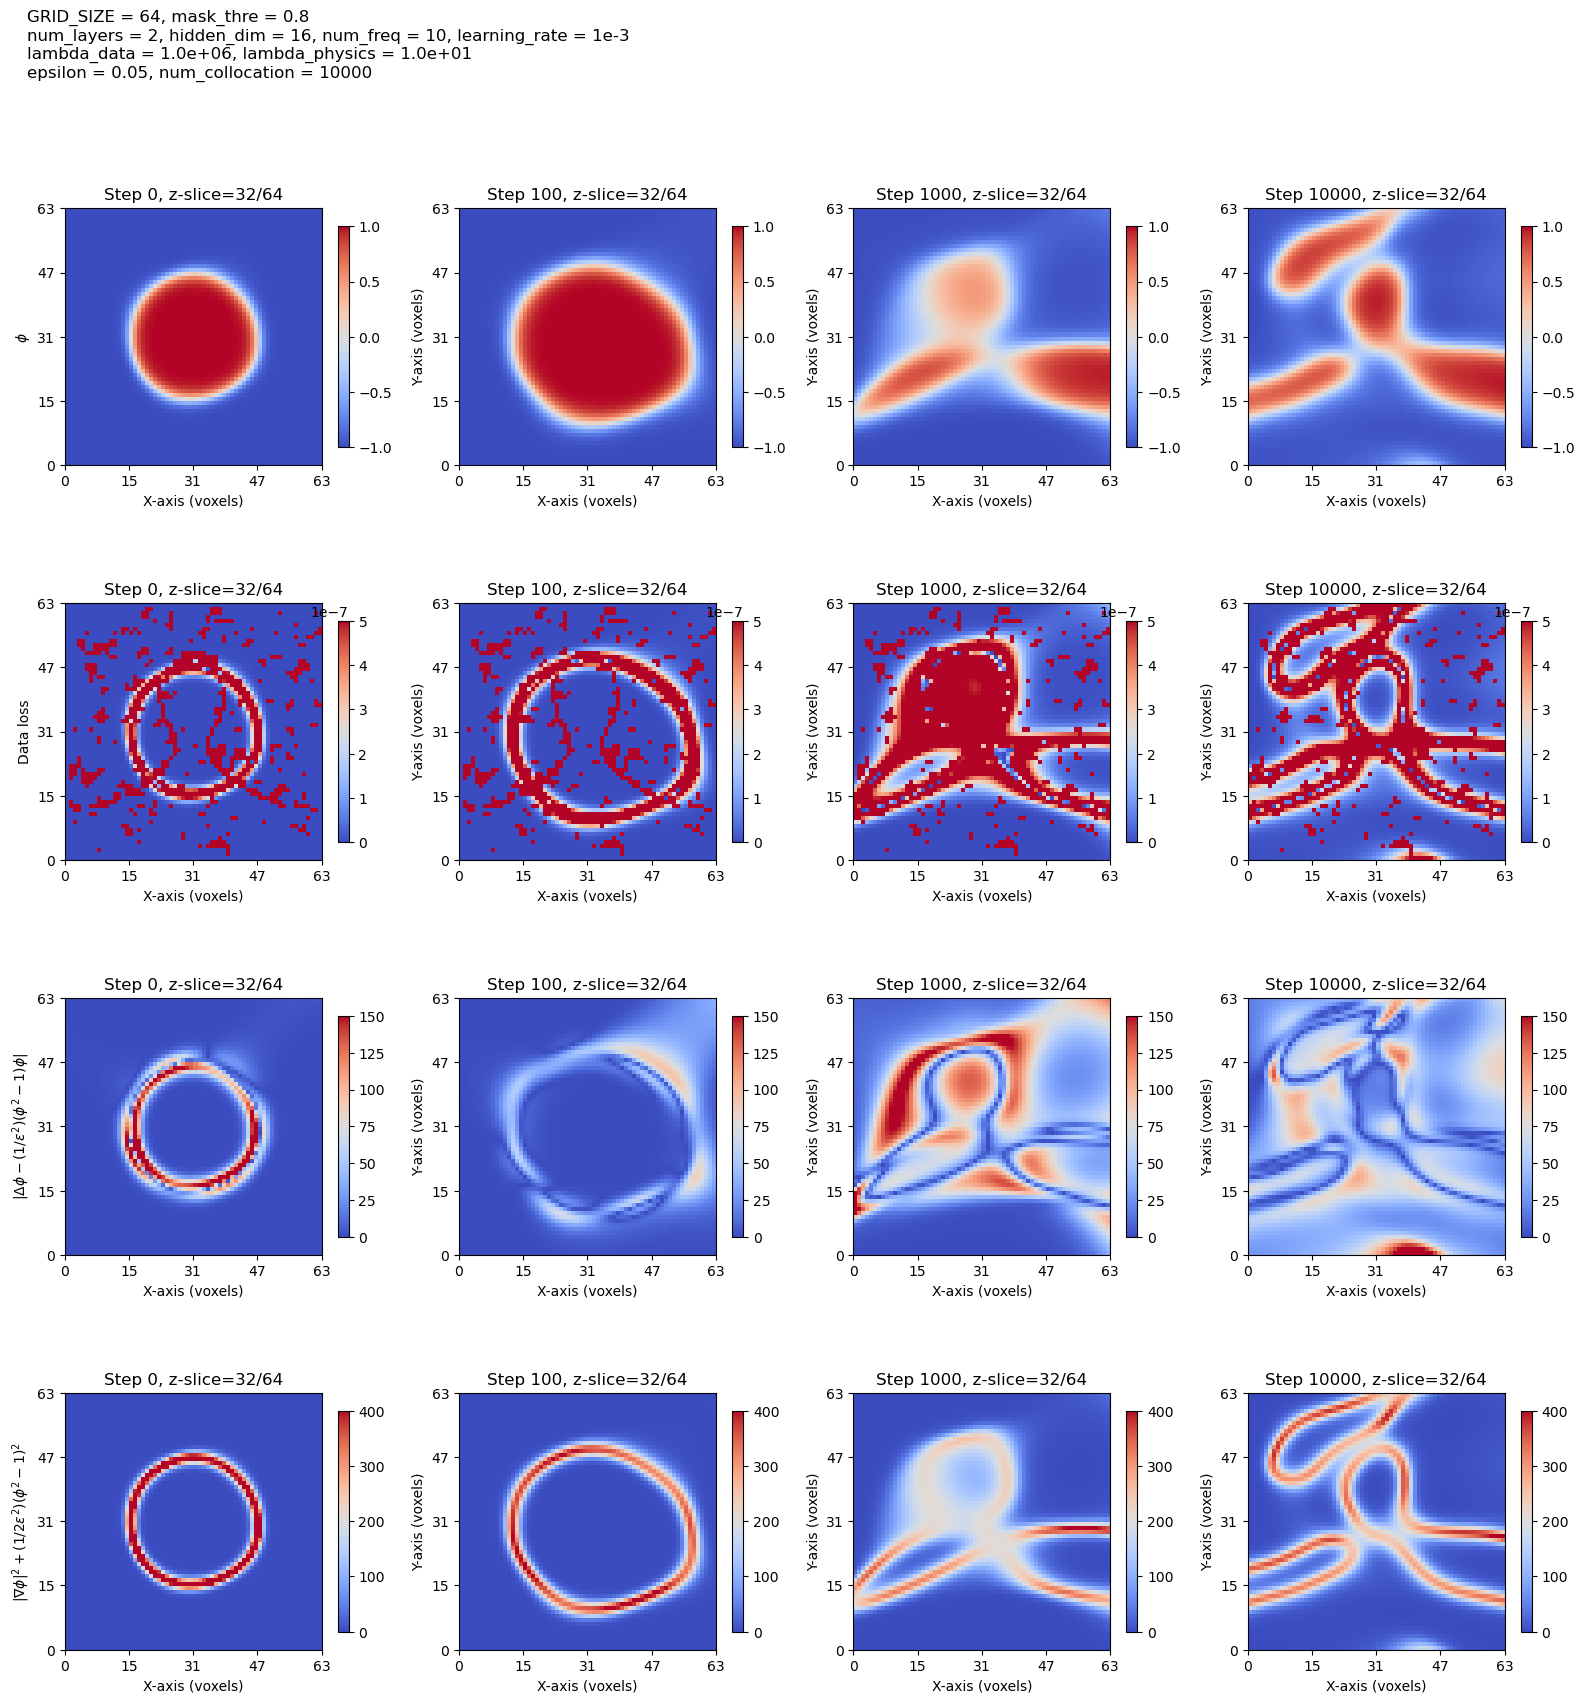

In [6]:
## make one combined physics analysis image

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
# lambda_1 = 5000000
# lambda_2 = 1
num_collocation = 10000
num_layers = 2
epsilon = 0.05
# shape = "multi"

# steps_to_visualize = [0, 200, 600, 1000]
# steps_to_visualize = [0, 2000, 6000, 10000]
# steps_to_visualize = [0, 1000, 6000, 10000]
steps_to_visualize = [0, 100, 1000, 10000]
# steps_to_visualize = [0, 10000, 20000, 30000]
# steps_to_visualize = [0, 30000, 60000, 90000]

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
# mrc_file_path = f"../data/synthetic/{shape}.mrc"
mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)


# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(4*4, 4*4))


# Row 1: Phi
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="phi",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=-1, vmax=1)
    # visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z", colorbar = True)
    if i == 0:
        ax.set_ylabel(r"$\phi$")

# Row 2: data loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="data",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=5e-7, cryoET_data=cryoET_data)
    if i == 0:
        ax.set_ylabel(r"Data loss")

# Row 3: physics loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="residual",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=150)

    if i == 0:
        ax.set_ylabel(r"$|\Delta \phi - (1/\epsilon^2)(\phi^2 - 1)\phi|$")

# Row 4: tension energy
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 12 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="tension",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=400)
    if i == 0:
        ax.set_ylabel(r"$|\nabla \phi|^2 + (1/2\epsilon^2) (\phi^2 -1)^2$")
        # ax.set_ylabel(r"$|\nabla\phi|^2$")


info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = {epsilon}, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/physics.png", dpi=300, bbox_inches="tight")
plt.show()